   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 1.0 MB/s eta 0:00:02
   ------------------ --------------------- 0.8/1.7 MB 1.0 MB/s eta 0:00:01
   ------------------------- -------------- 1.0/1.7 MB 1.0 MB/s eta 0:00:01
   ------------------------------- -------- 1.3/1.7 MB 982.7 kB/s eta 0:00:01
   ------------------------------- -------- 1.3/1.7 MB 982.7 kB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 1.0 MB/s  0:00:01

   ----------------------------------------  0/11 [pytz]
   ----------------------------------------  0/11 [pytz]
   --- ------------------------------------  1/11 [peewee]
   ---------- -----------------------------  3/11 [websockets]
   -------------- ------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
# first testing by downloading only one stock
import pandas as pd 
import yfinance as yf

wipro = yf.download ("WIPRO.NS", start="2022-01-01", end="2025-01-01")
print(wipro.head())
print(wipro.shape)

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker        WIPRO.NS    WIPRO.NS    WIPRO.NS    WIPRO.NS  WIPRO.NS
Date                                                                
2022-01-03  332.003174  335.744954  330.755904  331.679803   9280810
2022-01-04  333.296661  334.035770  328.700257  333.874098  10228800
2022-01-05  329.601044  332.996362  324.750573  332.603716  14711264
2022-01-06  326.020935  329.023608  323.341633  326.044027  12883220
2022-01-07  328.677124  333.296620  326.875509  327.060301  13120326
(739, 5)


In [43]:
# I am now downloading all 3 stocks together now
tickers = ["WIPRO.NS", "BSOFT.NS", "COFORGE.NS"]
data = yf.download(tickers, start="2022-01-01", end="2025-01-01")["Close"]
print(data.head())
print(data.shape)


[*********************100%***********************]  3 of 3 completed

Ticker        BSOFT.NS   COFORGE.NS    WIPRO.NS
Date                                           
2022-01-03  537.986633  1131.820190  332.003174
2022-01-04  531.012146  1156.879395  333.296661
2022-01-05  522.804138  1125.444092  329.601044
2022-01-06  530.774841  1123.861694  326.020935
2022-01-07  547.807983  1090.711426  328.677124
(739, 3)


In [44]:
# Calculating daily percentage now
returns = data.pct_change().dropna()
print(returns.head())


Ticker      BSOFT.NS  COFORGE.NS  WIPRO.NS
Date                                      
2022-01-04 -0.012964    0.022141  0.003896
2022-01-05 -0.015457   -0.027172 -0.011088
2022-01-06  0.015246   -0.001406 -0.010862
2022-01-07  0.032091   -0.029497  0.008147
2022-01-10 -0.009874   -0.030515 -0.025299


In [45]:
# Rolling Volatility
volatility = returns.rolling(window=30).std()*(252**0.5)
print(volatility.head(35))

Ticker      BSOFT.NS  COFORGE.NS  WIPRO.NS
Date                                      
2022-01-04       NaN         NaN       NaN
2022-01-05       NaN         NaN       NaN
2022-01-06       NaN         NaN       NaN
2022-01-07       NaN         NaN       NaN
2022-01-10       NaN         NaN       NaN
2022-01-11       NaN         NaN       NaN
2022-01-12       NaN         NaN       NaN
2022-01-13       NaN         NaN       NaN
2022-01-14       NaN         NaN       NaN
2022-01-17       NaN         NaN       NaN
2022-01-18       NaN         NaN       NaN
2022-01-19       NaN         NaN       NaN
2022-01-20       NaN         NaN       NaN
2022-01-21       NaN         NaN       NaN
2022-01-24       NaN         NaN       NaN
2022-01-25       NaN         NaN       NaN
2022-01-27       NaN         NaN       NaN
2022-01-28       NaN         NaN       NaN
2022-01-31       NaN         NaN       NaN
2022-02-01       NaN         NaN       NaN
2022-02-02       NaN         NaN       NaN
2022-02-03 

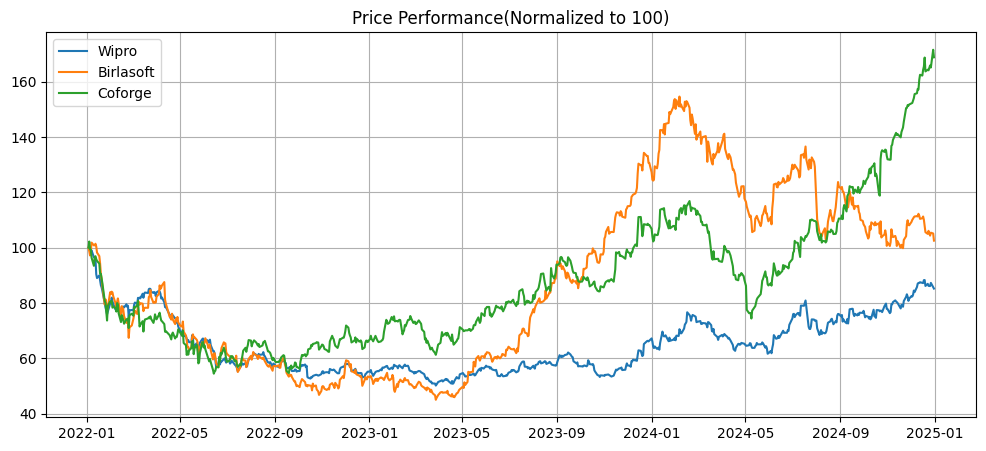

In [46]:
# prices to 100 so that we can compare
import matplotlib.pyplot as plt
normalized = data / data.iloc[0]*100

plt.figure(figsize=(12,5))
plt.plot(normalized["WIPRO.NS"], label="Wipro")
plt.plot(normalized["BSOFT.NS"], label="Birlasoft")
plt.plot(normalized["COFORGE.NS"], label="Coforge")
plt.title("Price Performance(Normalized to 100)")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
# calculating RSI for Wipro now
def calculate_rsi(series,period=14):
    delta = series.diff()
    gain = delta.where(delta>0,0).rolling(period).mean()
    loss = -delta.where(delta<0,0).rolling(period).mean()
    rs = gain / loss
    return 100 - (100/(1 + rs))
rsi = data.apply(calculate_rsi)
print(rsi.tail(10))


Ticker       BSOFT.NS  COFORGE.NS   WIPRO.NS
Date                                        
2024-12-17  57.585087   95.034194  74.541582
2024-12-18  61.117079   96.724625  89.143209
2024-12-19  49.119713   97.237413  88.211626
2024-12-20  33.626249   75.574579  68.268569
2024-12-23  27.602957   76.099889  71.695648
2024-12-24  31.683238   74.462211  64.986814
2024-12-26  24.896308   75.376572  58.805564
2024-12-27  29.066059   71.314883  66.906531
2024-12-30  27.963936   77.435007  49.925918
2024-12-31  23.806946   69.200683  40.000042


<function matplotlib.pyplot.show(close=None, block=None)>

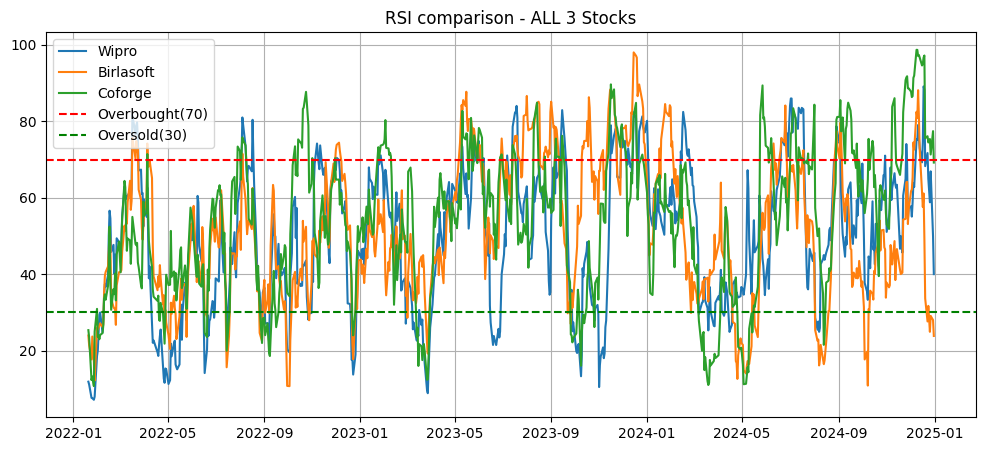

In [48]:
plt.figure(figsize=(12,5))
plt.plot(rsi["WIPRO.NS"], label="Wipro")
plt.plot(rsi["BSOFT.NS"], label="Birlasoft")
plt.plot(rsi["COFORGE.NS"], label="Coforge")
plt.axhline(70, color="red", linestyle="--", label="Overbought(70)")
plt.axhline(30, color="green", linestyle="--", label="Oversold(30)")
plt.title("RSI comparison - ALL 3 Stocks")
plt.legend()
plt.grid(True)
plt.show

In [49]:
corr = returns.corr()
print(corr)

Ticker      BSOFT.NS  COFORGE.NS  WIPRO.NS
Ticker                                    
BSOFT.NS    1.000000    0.526564  0.540529
COFORGE.NS  0.526564    1.000000  0.534531
WIPRO.NS    0.540529    0.534531  1.000000


<Figure size 1200x500 with 0 Axes>

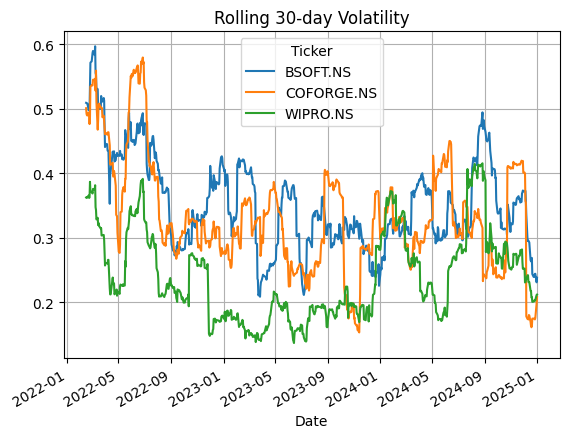

In [50]:
plt.figure(figsize=(12,5))
volatility.plot()
plt.title("Rolling 30-day Volatility")
plt.grid(True)
plt.show()

In [51]:
# Now to Find oversold dates for all 3 stocks
oversold = rsi[rsi < 30]
print("Oversold instances:")
print(oversold.dropna(how='all'))

Oversold instances:
Ticker       BSOFT.NS  COFORGE.NS   WIPRO.NS
Date                                        
2022-01-20  23.924406   25.331505  11.836374
2022-01-21  21.372119   23.404909  11.087036
2022-01-24  17.645306   12.252047   7.601120
2022-01-25  23.658753   13.206690   7.512077
2022-01-27  17.237736   10.678632   7.100300
...               ...         ...        ...
2024-12-23  27.602957         NaN        NaN
2024-12-26  24.896308         NaN        NaN
2024-12-27  29.066059         NaN        NaN
2024-12-30  27.963936         NaN        NaN
2024-12-31  23.806946         NaN        NaN

[185 rows x 3 columns]


In [52]:
# What happenes 10 days AFTER RSI went below 30?
future_returns = []
for date in oversold.dropna(how='all').index:
    idx = returns.index.get_loc(date)
    if idx + 10 < len(returns):
        fwd = returns.iloc[idx:idx+10].mean() * 10
        future_returns.append(fwd)

fwd_df = pd.DataFrame(future_returns)
print("Average 10-day forward return after oversold signal:")
print(fwd_df.mean())

Average 10-day forward return after oversold signal:
Ticker
BSOFT.NS     -0.005385
COFORGE.NS   -0.006864
WIPRO.NS     -0.013091
dtype: float64


In [53]:
sharpe = (returns.mean() / returns.std()) * (252**0.5)
print("Sharpe Ratios:")
print(sharpe)

Sharpe Ratios:
Ticker
BSOFT.NS      0.204573
COFORGE.NS    0.689537
WIPRO.NS     -0.089562
dtype: float64


In [54]:
print("Average Daily Return:")
print(returns.mean() * 100)
print("\nAnnualised Volatility:")
print(returns.std() * (252**0.5) * 100)

Average Daily Return:
Ticker
BSOFT.NS      0.029384
COFORGE.NS    0.094649
WIPRO.NS     -0.008977
dtype: float64

Annualised Volatility:
Ticker
BSOFT.NS      36.196422
COFORGE.NS    34.590534
WIPRO.NS      25.258342
dtype: float64


In [55]:
prices_long = data.reset_index().melt(
    id_vars="Date",
    var_name="Stock",
    value_name="Close"
)

normalized_long = normalized.reset_index().melt(
    id_vars="Date",
    var_name="Stock",
    value_name="NormalizedPrice"
)

stock_prices = prices_long.merge(normalized_long, on=["Date", "Stock"])
stock_prices.to_csv("stock_prices.csv", index=False)

returns_long = returns.reset_index().melt(
    id_vars="Date",
    var_name="Stock",
    value_name="DailyReturn"
)

volatility_long = volatility.reset_index().melt(
    id_vars="Date",
    var_name="Stock",
    value_name="RollingVolatility30D"
)

rsi_long = rsi.reset_index().melt(
    id_vars="Date",
    var_name="Stock",
    value_name="RSI14"
)

stock_returns = returns_long.merge(volatility_long, on=["Date", "Stock"])
stock_returns = stock_returns.merge(rsi_long, on=["Date", "Stock"])
stock_returns.to_csv("stock_returns.csv", index=False)

summary = pd.DataFrame({
    "Stock": sharpe.index,
    "AverageDailyReturn": returns.mean().values,
    "AnnualizedVolatility": (returns.std() * (252 ** 0.5)).values,
    "SharpeRatio": sharpe.values,
    "Avg10DayForwardReturnAfterOversold": fwd_df.mean().values
})
summary.to_csv("stock_summary.csv", index=False)

corr_long = corr.reset_index().melt(
    id_vars="Ticker",
    var_name="Stock2",
    value_name="Correlation"
).rename(columns={"Ticker": "Stock1"})
corr_long.to_csv("correlation_matrix.csv", index=False)